# Proyecto: Predicción inteligente de gasto en clientes e-commerce
### Francisca Rojas González

## Preparación y revisión de Datos

## 🛒 Conjunto de datos de ventas y comportamiento del cliente de comercio electrónico

📊 Descripción general del conjunto de datos
Este conjunto de datos integral contiene 5000 transacciones de comercio electrónico de una plataforma minorista en línea turca, que abarcan desde enero de 2023 hasta marzo de 2024. El conjunto de datos proporciona información detallada sobre la demografía de los clientes, el comportamiento de compra, las preferencias de productos y las métricas de participación.

##### Información del pedido
- Order_ID: Identificador único para cada pedido (formato ORD_XXXXXX)
- Date: Fecha de la transacción (del 01/01/2023 al 26/03/2024)

##### Datos demográficos del cliente
- Customer_ID: Identificador único del cliente (formato CUST_XXXXX)
- Age: Edad del cliente (18-75 años)
- Gender: Género del cliente (Hombre, Mujer, Otro)
- City: Ciudad del cliente (10 ciudades turcas principales)

##### Información del producto
- Product_Category: 8 categorías (Electrónica, Moda, Hogar y jardín, Deportes, Libros, Belleza, Juguetes, Comida)
- Unit_Price: Precio por unidad (en TRY/lira turca)
- Quantity: Número de unidades compradas (1-5)

##### Detalles de la transacción
- Discount_Amount: Descuento aplicado (si lo hay)
- Total_Amount: Importe final de la transacción después del descuento
- Payment_Method: Método de pago utilizado (5 tipos)

##### Métricas del comportamiento del cliente
- Device_Type: Dispositivo utilizado para la compra (Móvil, Escritorio, Tableta)
- Session_Duration_Minutes: Tiempo empleado en el sitio web (1-120 minutos)
- Pages_Viewed: Número de páginas vistas durante la sesión (1-50)
- Is_Returning_Customer: Si el cliente ha comprado antes (Verdadero/Falso)

##### Métricas posteriores a la compra
- Delivery_Time_Days: Duración de la entrega (1-30 días)
- Customer_Rating: Calificación de satisfacción del cliente (1-5 estrellas)

## 🛠️ Detalles técnicos

Formato de archivo: CSV (valores separados por comas)
Codificación: UTF-8
Tamaño de archivo: ~500 KB
Delimitador: coma (,)

## 📝 Cita

Conjunto de datos de comportamiento de clientes y ventas de comercio electrónico (2024).
Datos de la plataforma de comercio electrónico turco (2023-2024).
Disponible en Kaggle

In [1]:
# -------- CARGAR LIBRERÍAS Y FUNCIONES --------- #
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, cross_val_score, KFold, cross_validate, GridSearchCV
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score, classification_report, 
accuracy_score, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.ensemble import GradientBoostingRegressor

In [2]:
# -------- CARGAR DATA: PRIMERA VISUALIZACIÓN --------- #
df = pd.read_csv("ecommerce_customer_behavior_dataset.csv")
df.head()

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_001337,CUST_01337,2023-01-01,27,Female,Bursa,Toys,54.28,1,0.00,54.28,Debit Card,Mobile,4,14,True,8,5
1,ORD_004885,CUST_04885,2023-01-01,42,Male,Konya,Toys,244.90,1,0.00,244.90,Credit Card,Mobile,11,3,True,3,3
2,ORD_004507,CUST_04507,2023-01-01,43,Female,Ankara,Food,48.15,5,0.00,240.75,Credit Card,Mobile,7,8,True,5,2
3,ORD_000645,CUST_00645,2023-01-01,32,Male,Istanbul,Electronics,804.06,1,229.28,574.78,Credit Card,Mobile,8,10,False,1,4
4,ORD_000690,CUST_00690,2023-01-01,40,Female,Istanbul,Sports,755.61,5,0.00,3778.05,Cash on Delivery,Desktop,21,10,True,7,4


In [3]:
# ------- REVISIÓN GENERAL COLUMNAS Y TIPO DE DATOS ---------
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  5000 non-null   str    
 1   Customer_ID               5000 non-null   str    
 2   Date                      5000 non-null   str    
 3   Age                       5000 non-null   int64  
 4   Gender                    5000 non-null   str    
 5   City                      5000 non-null   str    
 6   Product_Category          5000 non-null   str    
 7   Unit_Price                5000 non-null   float64
 8   Quantity                  5000 non-null   int64  
 9   Discount_Amount           5000 non-null   float64
 10  Total_Amount              5000 non-null   float64
 11  Payment_Method            5000 non-null   str    
 12  Device_Type               5000 non-null   str    
 13  Session_Duration_Minutes  5000 non-null   int64  
 14  Pages_Viewed       

In [4]:
# -------- VISUALIZACIÓN DE ESTADISTICAS GENERALES DE DATOS NUMÉRICOS --------
df.describe()

,Age,Unit_Price,Quantity,Discount_Amount,Total_Amount,Session_Duration_Minutes,Pages_Viewed,Delivery_Time_Days,Customer_Rating
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.00000,5000.000000,5000.000000
mean,35.032600,455.834120,2.220000,24.852804,983.108914,14.57340,8.98420,6.497000,3.902800
std,11.080546,712.477209,1.398711,88.385124,1898.978528,8.66575,2.80434,3.464966,1.128542
min,18.000000,5.180000,1.000000,0.000000,7.870000,1.00000,1.00000,1.000000,1.000000
25%,27.000000,76.587500,1.000000,0.000000,122.517500,8.00000,7.00000,4.000000,3.000000
50%,35.000000,182.950000,2.000000,0.000000,337.910000,13.00000,9.00000,6.000000,4.000000
75%,42.000000,513.930000,3.000000,8.760000,979.695000,19.00000,11.00000,8.000000,5.000000
max,75.000000,7159.450000,5.000000,1525.550000,22023.900000,73.00000,24.00000,25.000000,5.000000


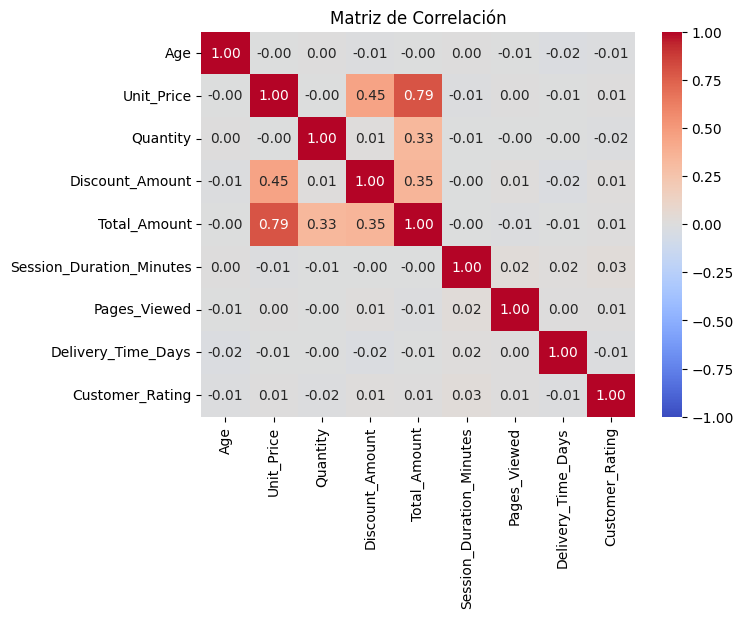

In [5]:
# -------- VISUALIZAR RELACIONES VARIABLES NUMÉRICAS -------- #

# Matriz de Correlación: Coeficiente de Pearson (R)
corr_matrix = df.select_dtypes(include=[np.number]).corr()

# Visualización con Heatmap 
plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1 )
plt.title('Matriz de Correlación')
plt.show()

### Análisis de la Matriz de Correlación (EDA)

Dado que la variable objetivo es `Total_Amount`, el análisis se centra en identificar qué variables presentan mayor relación lineal con ella.

#### Variables con mayor correlación positiva

- **Unit_Price (0.79)** → Presenta una correlación fuerte y positiva con `Total_Amount`. Esto es coherente, ya que el monto total depende directamente del precio unitario.
- **Discount_Amount (0.35)** → Correlación positiva moderada. Puede indicar que compras más grandes tienden a tener mayores descuentos aplicados.
- **Quantity (0.33)** → Correlación positiva moderada. También es lógico, ya que una mayor cantidad comprada incrementa el monto total.

Estas tres variables son las más relevantes desde una perspectiva lineal y probablemente serán predictoras importantes en el modelo de regresión.

#### Variables con baja o nula correlación

Las siguientes variables muestran correlaciones cercanas a 0:

- `Age`
- `Session_Duration_Minutes`
- `Pages_Viewed`
- `Delivery_Time_Days`
- `Customer_Rating`

Esto sugiere que no existe una relación lineal fuerte entre estas variables y el monto total de compra. Sin embargo, una baja correlación no implica necesariamente que la variable no sea útil, ya que podría aportar valor en modelos no lineales (como árboles de decisión o modelos de boosting).

#### Posible multicolinealidad

Se observa que:

- `Unit_Price` también está correlacionado con `Discount_Amount` (0.45).
- `Total_Amount` depende estructuralmente de `Unit_Price` y `Quantity`.

Este análisis preliminar sugiere que el monto de compra está principalmente determinado por variables transaccionales más que por variables de comportamiento o satisfacción del cliente.

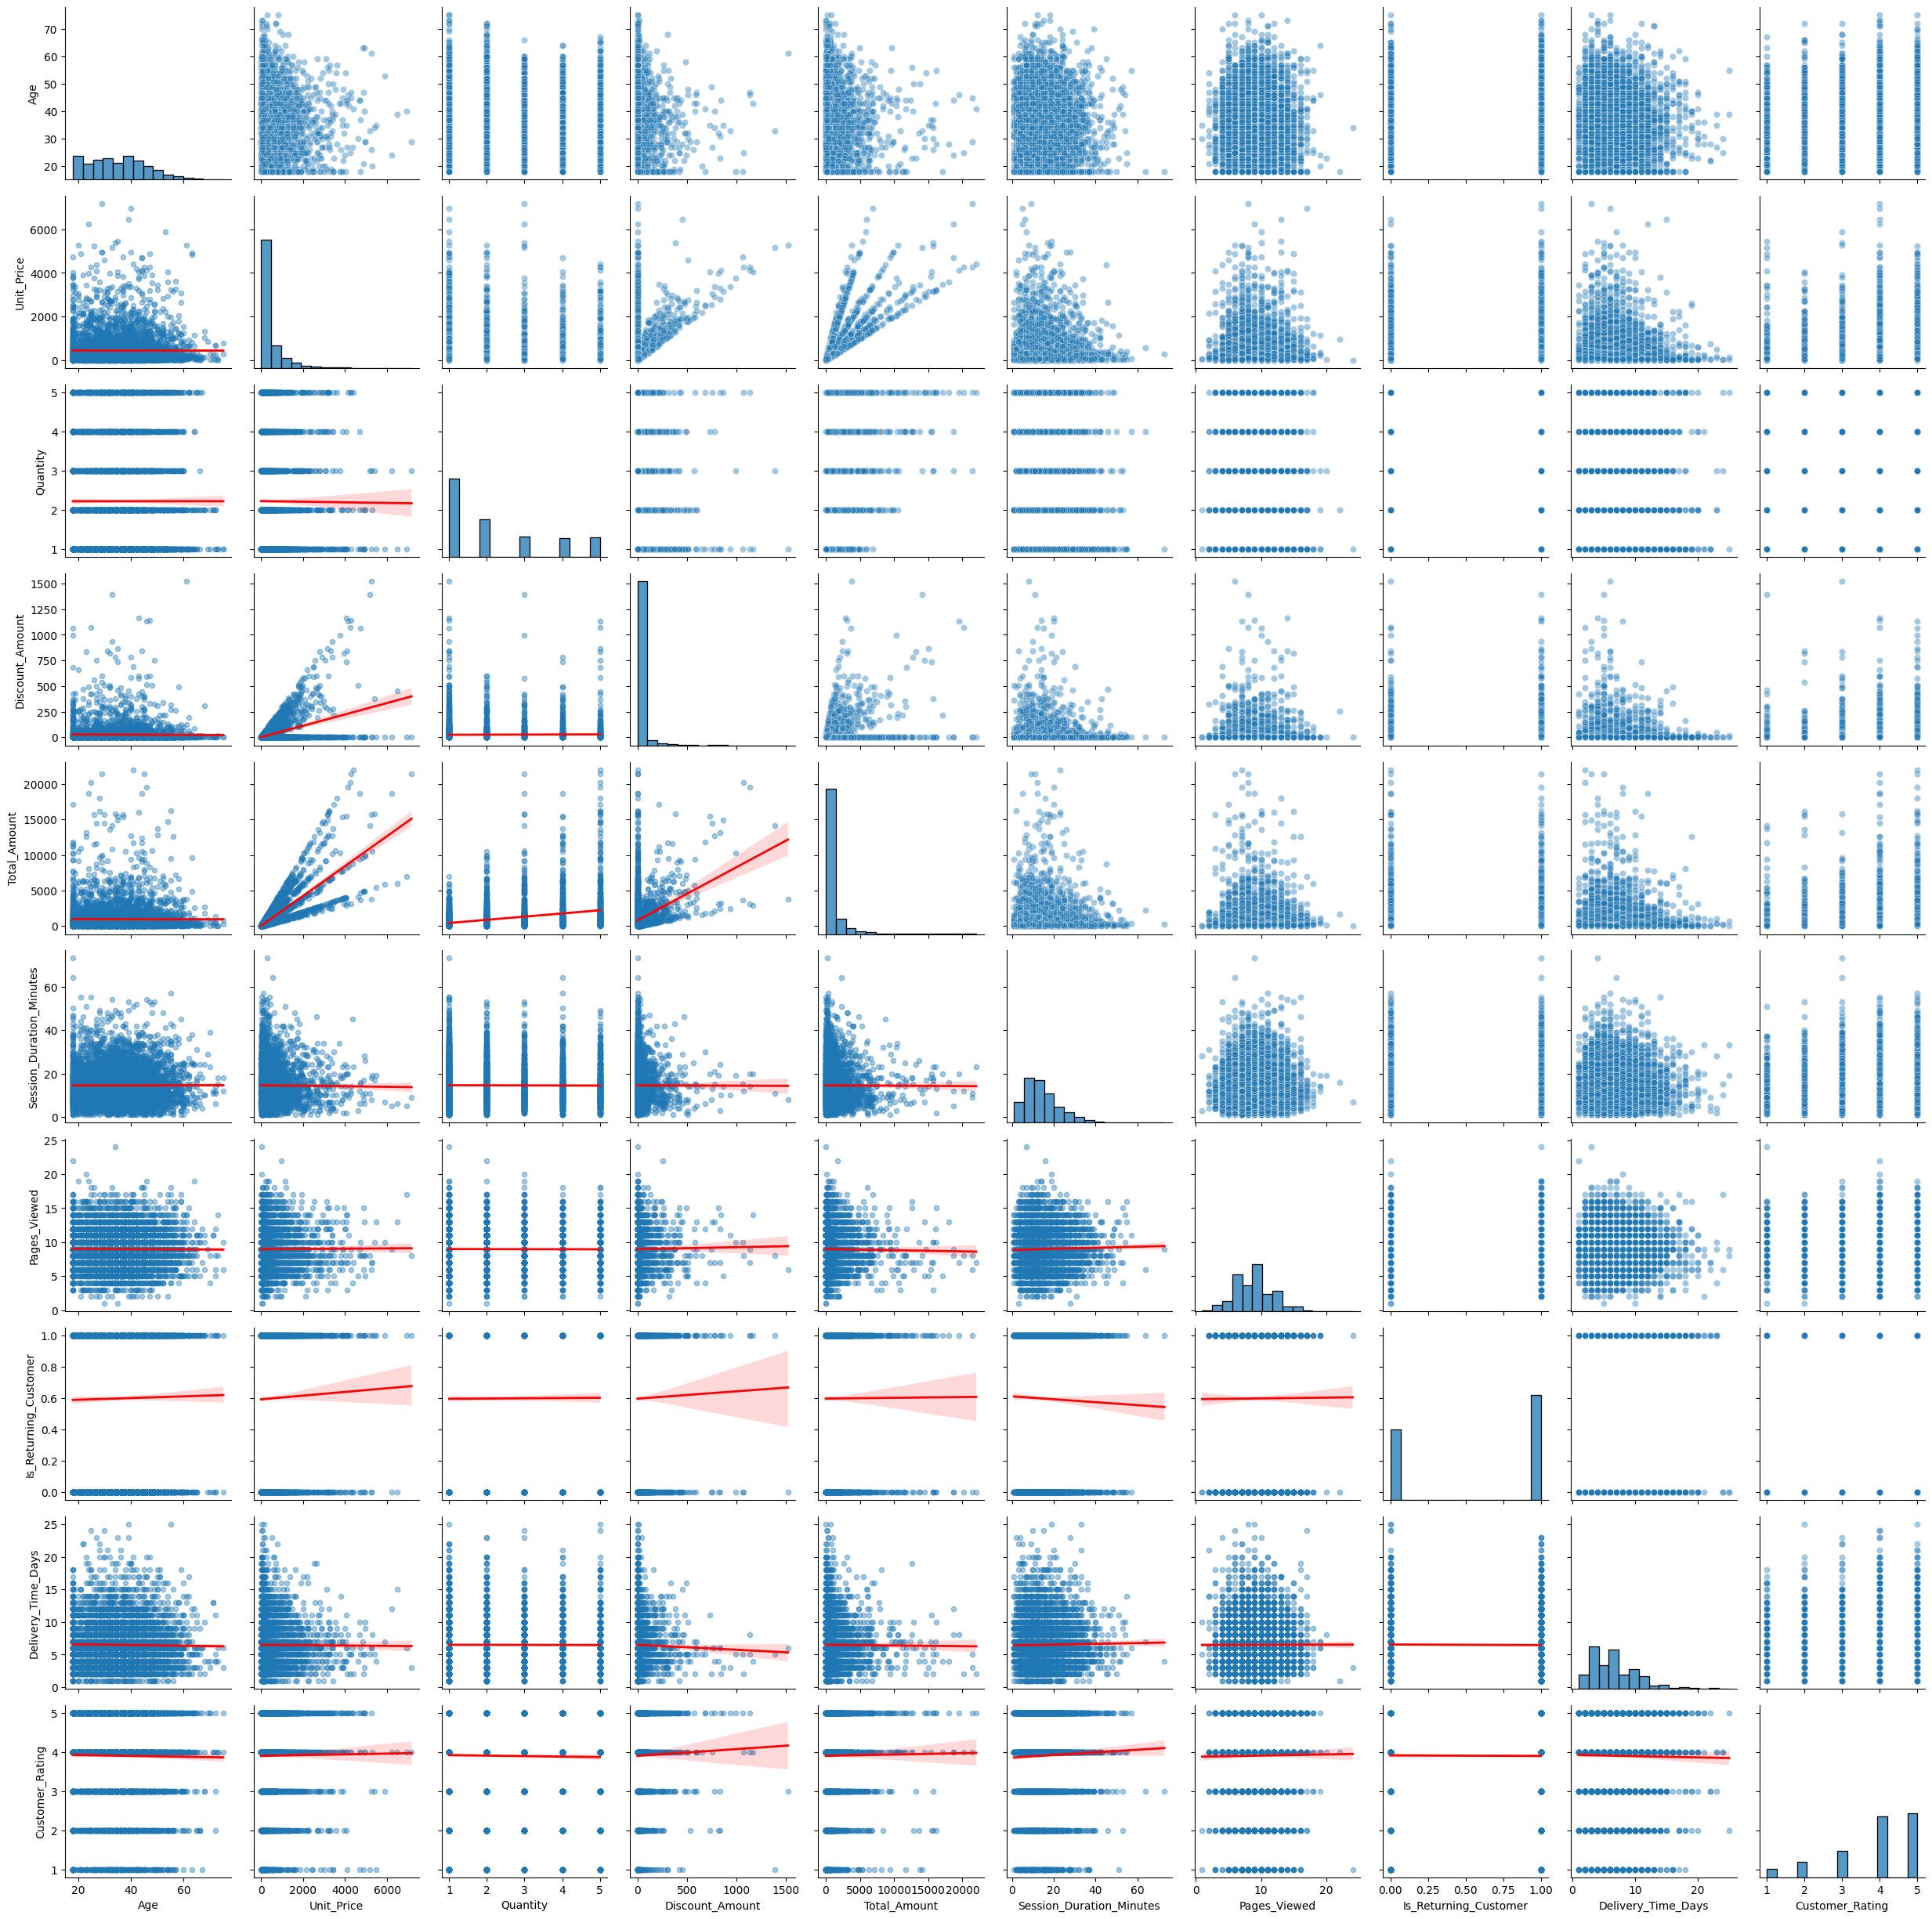

In [6]:
# ------- VISUALIZACIÓN DE RELACIONES ENTRE VARIABLES NUMÉRICAS ------- #
g = sns.PairGrid(df)
g.map_upper(sns.scatterplot, alpha=0.4)
g.map_diag(sns.histplot, bins=15)
g.map_lower(sns.regplot, scatter_kws={"alpha":0.4, "s": 20}, ci=95, line_kws={"lw": 2,'color':'red'})
plt.show()

### Análisis del PairGrid (EDA)

La relación entre `Total_Amount` y las variables transaccionales **Unit_Price vs Total_Amount**, **Quantity vs Total_Amount**, **Discount_Amount vs Total_Amount**, se observa con mayor claridad y muestran relaciones lineales positivas. En conjunto, estas tres variables muestran patrones consistentes y estructuralmente coherentes con la construcción del monto total.

Hay variables con baja relación aparente con `Total_Amount`, son el caso de `Age`, `Session_Duration_Minutes` y `Pages_Viewed` (esto sugiere que el comportamiento de navegación no impacta directamente el valor monetario de la compra, al menos desde una perspectiva lineal), `Delivery_Time_Days` y `Customer_Rating`.

En cuanto a las distribuciones individuales:

- `Total_Amount` presenta una distribución sesgada hacia la derecha, con presencia de valores altos extremos.
- `Unit_Price` también muestra asimetría positiva.
- `Discount_Amount` tiene concentración en valores bajos y algunos valores extremos.

Esto sugiere, posible presencia de outliers, lo que se evaluará la necesidad de transformación, para mejorar estabilidad del modelo.

A tener en cuenta:
- Presencia otuliers.
- Revisar colinealidad.
- Probar modelos no lineales que puedan capturar interacciones adicionales.

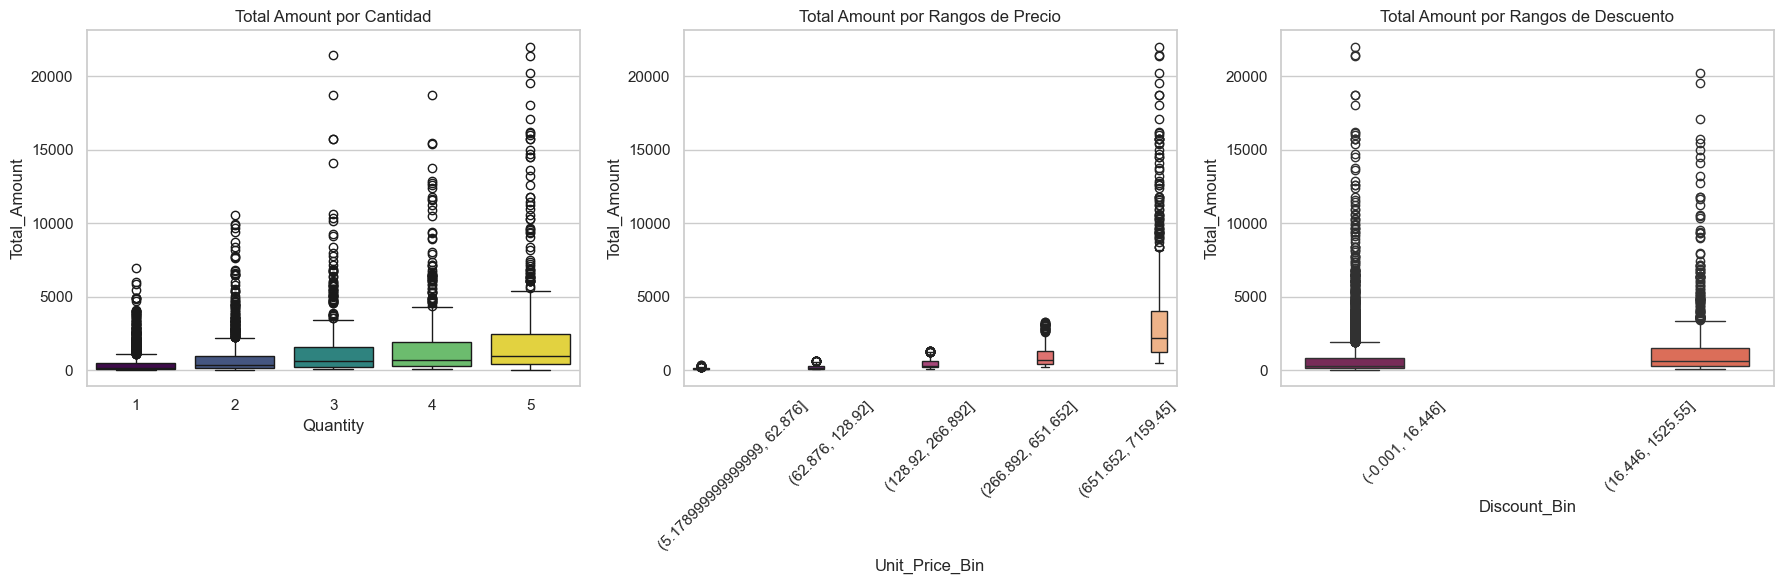

In [7]:
# ------- VISUALIZACIÓN DE BOXPLOT PARA DISTRIBUCIÓN TOTAL_AMOUNT EN VARIABLES CLAVE ------

# Configuración estética
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Quantity vs Total_Amount
sns.boxplot(ax=axes[0], x='Quantity', y='Total_Amount', data=df, hue='Quantity', palette='viridis', legend=False)
axes[0].set_title('Total Amount por Cantidad')

# Unit_Price vs Total_Amount (con bins)
if 'Unit_Price_Bin' not in df.columns:
    df['Unit_Price_Bin'] = pd.qcut(df['Unit_Price'], q=5)

sns.boxplot(ax=axes[1], x='Unit_Price_Bin', y='Total_Amount', data=df, hue='Unit_Price_Bin', palette='magma', legend=False)
axes[1].set_title('Total Amount por Rangos de Precio')
axes[1].tick_params(axis='x', rotation=45)

# Discount_Amount vs Total_Amount (con bins)
if 'Discount_Bin' not in df.columns:
    df['Discount_Bin'] = pd.qcut(df['Discount_Amount'], q=5, duplicates='drop')

sns.boxplot(ax=axes[2], x='Discount_Bin', y='Total_Amount', data=df, hue='Discount_Bin', palette='rocket', legend=False)
axes[2].set_title('Total Amount por Rangos de Descuento')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Análisis Boxplot
- Outliers Extremos: En los tres gráficos, el Total_Amount llega hasta sobre los 20,000, pero la gran mayoría de los datos está por debajo de los 2,500. Estos son compras atípicas que podrían sesgar cualquier modelo lineal, haciendo que prediga valores más altos de lo normal para clientes promedio.

- Heterocedasticidad: Al mirar el gráfico de Rangos de Precio. En el primer rango, la caja es pequeña; en el último rango (precios altos), la dispersión es muy grande. Esto significa que el error de predicción será mayor a medida que el producto sea más caro.

- Impacto de la Cantidad: Aunque la mediana sube poco con la cantidad, la dispersión crece mucho más. Un cliente que compra 5 unidades es mucho más impredecible que uno que compra 1.

## Nivel de ajuste del modelo y validación cruzada

#### Ajuste inicial sin tratamiento de datos

Se decide hacer un ajuste inicial crudo, sin tratar las variables numéricas, solo categóricas para que el ajuste sea funcional. Esto con el objetivo de visualizar como el manejo previo de los datos y el preprocesamiento influyen en la calidad del modelo.

In [8]:
# ------- APLICACIÓN DE MODELO INICIAL SIN TRATAMIENTO DE VARIABLES --------

# Definición de columnas
target = 'Total_Amount'
num_features = ['Age', 'Quantity', 'Unit_Price', 'Discount_Amount', 'Session_Duration_Minutes', 'Pages_Viewed', 
    'Delivery_Time_Days', 'Customer_Rating', 'Is_Returning_Customer']
cat_features = ['Gender', 'City', 'Product_Category', 'Payment_Method', 'Device_Type']

# Selección de datos
X = df[num_features + cat_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocesamiento Mínimo: Solo Categorías
preprocessor = ColumnTransformer(transformers=[
        ('num', 'passthrough', num_features), # No hace nada, deja los números como están
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features)])

# Aplicamos la transformación
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

# Entrenamiento del Modelo Base (Sin escalar y sin tratar outliers)
model = LinearRegression()
model.fit(X_train_prep, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [9]:
# ------- PREDICCIONES Y MÉTRICAS -------

# Predicciones para entrenamiento y prueba
y_train_pred = model.predict(X_train_prep)
y_test_pred = model.predict(X_test_prep)

# Cálculo de métricas
metrics = {
    'MAE': [mean_absolute_error(y_train, y_train_pred), mean_absolute_error(y_test, y_test_pred)],
    'RMSE': [np.sqrt(mean_squared_error(y_train, y_train_pred)), np.sqrt(mean_squared_error(y_test, y_test_pred))],
    'R2': [r2_score(y_train, y_train_pred), r2_score(y_test, y_test_pred)]}

df_metrics = pd.DataFrame(metrics, index=['Entrenamiento', 'Prueba'])
print(df_metrics)
print("Media Total_Amount:", df['Total_Amount'].mean())

                      MAE         RMSE        R2
Entrenamiento  553.386618  1018.316762  0.737712
Prueba         484.019211   760.993418  0.734320
Media Total_Amount: 983.108914


Para el conjunto de entrenamiento el MAE es de ~553 y un RMSE de ~1018, casi el doble, y aun mayor que la media de Total_Amount.

Para el conjunto de prueba hay un MAE de ~484. Esto significa que, en promedio, el modelo se equivoca por 484 unidades monetarias al estimar el Total_Amount. Considerándolo frente a la mediana de los datos ~983, es un error bastante grande.

El RMSE (~761) es casi 1.6 veces más grande que el MAE.

Esto confirma que el modelo tiene errores muy grandes en unos pocos registros (los outliers que vimos en los boxplots). Como el RMSE eleva el error al cuadrado, esos valores extremos están "inflando" esta métrica.

Con estos valores ya se puede notar un subajuste, pues el modelo considera errores aun mayores con los datos de entrenamiento.

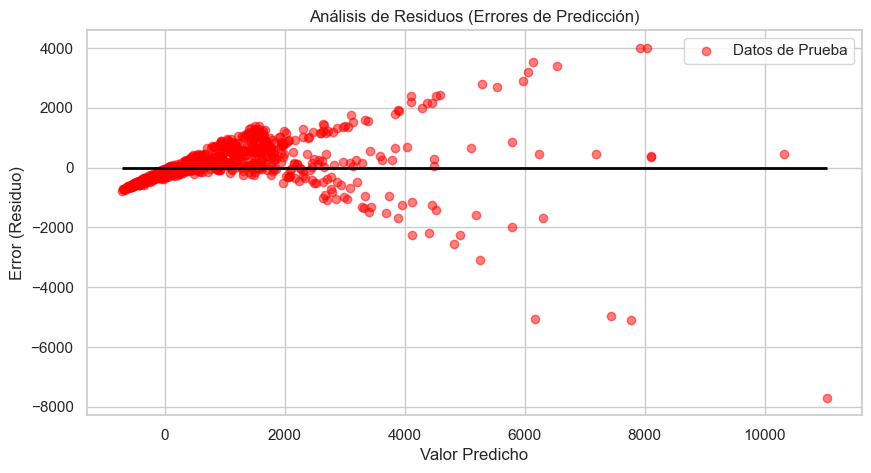

In [10]:
# -------- GRAFICO DE RESIDUOS (Análisis de errores) ---------
plt.figure(figsize=(10, 5))
plt.scatter(y_test_pred, y_test_pred - y_test, c='red', marker='o', label='Datos de Prueba', alpha=0.5)
plt.hlines(y=0, xmin=min(y_test_pred), xmax=max(y_test_pred), color='black', lw=2)
plt.title('Análisis de Residuos (Errores de Predicción)')
plt.xlabel('Valor Predicho')
plt.ylabel('Error (Residuo)')
plt.legend()
plt.show()

### Análisis gráfico

El gráfico muestra una forma de "embudo" o "abanico" (heterocedasticidad). A medida que el valor predicho aumenta, la dispersión del error es masiva (llegando a errores de -8,000 o +4,000). Esto indica que el modelo "crudo" es incapaz de manejar montos de compra altos de manera estable.

### Identificación de Sobreajuste y Subajuste

- ¿Hay Sobreajuste?
No. Las métricas de entrenamiento ($R^2 = 0.737$) y prueba ($R^2 = 0.734$) son prácticamente iguales. Si hubiera sobreajuste, el error de prueba sería significativamente peor que el de entrenamiento, y no lo es. El modelo está generalizando bien, pero generaliza un error alto.

- ¿Hay Subajuste? Sí. Aunque un $R^2$ de 0.73 no parece "tan malo", la forma de los residuos indica que una línea recta simple no es suficiente para capturar la naturaleza de estos datos. El modelo sufre de un sesgo alto. Es demasiado simple para capturar las relaciones complejas y los valores extremos.

- El modelo "ignora" los extremos. Al no estar escalado, variables con rangos grandes como Unit_Price (que llega a 7,000) dominan la ecuación, los outliers en Total_Amount (que llegan a 20,000) desvían la predicción de la mayoría de los casos promedio.

In [11]:
# ------- VALIDACIÓN CRUZADA ---------

# Definimos el método de división (K=5)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Calculamos el R2 para cada uno de los 5 experimentos
cv_scores = cross_val_score(model, X_train_prep, y_train, cv=kf, scoring='r2')

print(f"R2 por Fold: {cv_scores}")
print(f"R2 Promedio: {cv_scores.mean():.4f}")
print(f"Desviación Estándar de R2: {cv_scores.std():.4f}")

R2 por Fold: [0.74729356 0.71476377 0.72916677 0.70017214 0.76361174]
R2 Promedio: 0.7310
Desviación Estándar de R2: 0.0226


In [12]:
#Cálculo de MAE para validación cruzada
mae_scores = -cross_val_score(model,X_train_prep, y_train, cv=kf, scoring="neg_mean_absolute_error")

print("MAE por fold:", mae_scores)
print("MAE promedio:", np.mean(mae_scores))
print("Desviación estándar:", np.std(mae_scores))

MAE por fold: [532.89782457 583.92383158 535.17622851 611.00880433 542.14364016]
MAE promedio: 561.0300658312739
Desviación estándar: 31.108004723004623


### Análisis Validación cruzada

$R^2$ por fold oscilan entre 0.70 y 0.76. Y el hecho de que la desviación estándar sea tan baja (0.0226) indica que el modelo es estable. No importa qué "pedazo" de los datos usemos para entrenar, el resultado es similar. Esto descarta que el rendimiento anterior fuera producto del azar.

Los MAE siguen siendo estables, pero altos considerando la media de mi valor objetivo.

### Conclusiones
El error promedio representa casi el 57% del valor medio de compra ($561 / 983$). Desde una perspectiva de negocio, el modelo es actualmente poco útil. Este error es demasiado alto para tomar decisiones financieras o de inventario. Esto refuerza que, aunque el modelo es estable (según el K-Fold), su precisión es insuficiente debido a la falta de tratamiento de datos.

## Preprocesamiento y escalamiento de datos

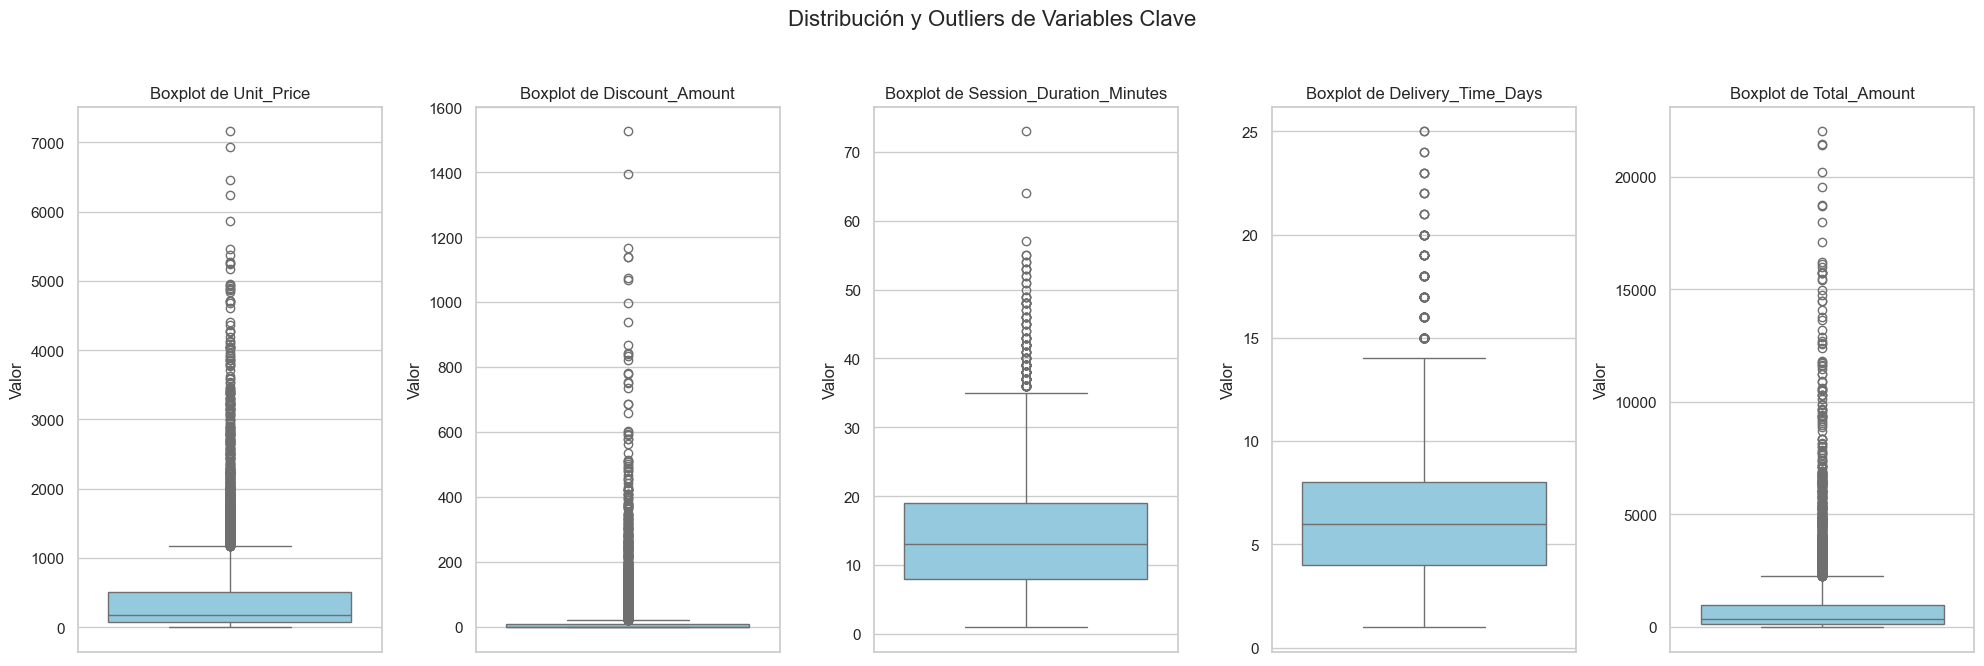

In [13]:
# ------- VISUALIZACIÓN OUTLIERS --------

# Seleccionamos las variables numéricas para observar presencia de outliers
vars_to_plot = ['Unit_Price', 'Discount_Amount', 'Session_Duration_Minutes', 'Delivery_Time_Days', 'Total_Amount']

# Configuración de la figura
fig, axes = plt.subplots(1, 5, figsize=(20, 7))
fig.suptitle('Distribución y Outliers de Variables Clave', fontsize=16)

# Generación de gráficos
for i, var in enumerate(vars_to_plot):
    sns.boxplot(y=df[var], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot de {var}')
    axes[i].set_ylabel('Valor')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Análisis boxplot

En `Unit_Price` y `Discount_Amount`, la "caja" (50% de lo datos) está comprimida en la parte inferior, casi pegada al cero. Existe una densidad masiva de outliers que se extiende hacia arriba de forma casi continua. En `Unit_Price`, hay valores que superan los 7,000, mientras que la mayoría de los productos cuestan menos de 500.

Dado estos hallazgos y considerando la forma de la distribución observada en los histogramas, se decide utilizar una tranformación logaritmica para el tratamiento de outliers, así no se pierde información sobre estas variables clave y la regresión no se ve mermada por estos valores atípicos. 

Para `Session_Duration_Minutes` y `Delivery_Time_Days` se encontraron Outliers Moderados. Muestran una distribución más balanceada, a pesar de sus valores atípicos. A diferencia de las anteriores, aquí los outliers están más dispersos y no definen la naturaleza de la variable, por lo que su impacto no debería ser tan grande. Para estas, con el escalado estándar (StandardScaler) debería ser suficiente para mitigar su impacto.

In [14]:
# ----- WINSORIZACIÓN -----
# Columnas con outliers
#cols_outliers = ['Unit_Price', 'Discount_Amount', 'Total_Amount']

#for col in cols_outliers:
#    p99 = df[col].quantile(0.99)
#    df[col] = df[col].clip(upper = p99)

### Alcances respecto a la Winsorización

Durante el análisis exploratorio se detectaron valores extremos en variables como `Unit_Price`, `Discount_Amount` y `Total_Amount`. Para evaluar su impacto, se aplicó winsorización limitando los valores entre los percentiles 99, y luego con 95. Sin embargo, al reentrenar los modelos se observó una disminución del rendimiento: el R² se redujo hasta cerca de un ~15% y las métricas de error aumentaron.

Estos resultados sugieren que los valores extremos contienen información relevante del comportamiento real de compra y que su truncamiento genera pérdida de señal para el modelo. Además, la heterocedasticidad en los residuos persistió incluso después de aplicar winsorización.

En contraste, la transformación logarítmica aplicada a `Total_Amount` permitió mejorar la distribución de la variable y estabilizar parcialmente la varianza sin eliminar información. Por esta razón, se decidió mantener únicamente la transformación logarítmica dentro del pipeline final de preprocesamiento.

In [14]:
# ------- FLUJO DE PREPROCESAMIENTO --------

# Se aplica log para aplanar las variables que tienen outliers extremos
num_log_features = ['Unit_Price', 'Discount_Amount']

# Variables numéricas que NO necesitan tranformación logaritmica
num_std_features = ['Age', 'Quantity', 'Session_Duration_Minutes', 
                    'Pages_Viewed', 'Delivery_Time_Days', 'Customer_Rating', 'Is_Returning_Customer']

# Variables Categóricas
cat_features = ['Gender', 'City', 'Product_Category', 'Payment_Method', 'Device_Type']

# División de variables
X = df[num_log_features + num_std_features + cat_features]
y = df['Total_Amount']

# Aplicamos Logaritmo a la variable objetivo para manejo de outliers
y_log = np.log1p(y)

# Separamos varibles de entrenamiento (0.8) y prueba (0.2)
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

# Pipeline para numéricas con LOG
log_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Trata nulos con la mediana
    ('log', FunctionTransformer(np.log1p, feature_names_out='one-to-one')), # Aplica log(1+x), mantiene nombres
    ('scaler', StandardScaler())                  # Estandariza
])

# Pipeline para numéricas ESTÁNDAR
std_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Imputar con mediana
    ('scaler', StandardScaler())                  # Estandariza
])

# Pipeline para CATEGÓRICAS
cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Trata nulos con la moda
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))   # Codificar con OneHotEncoder
])

# Unión en un ColumnTransformer (Preprocesador)
preprocessor = ColumnTransformer(transformers=[
        ('num_log', log_pipeline, num_log_features),
        ('num_std', std_pipeline, num_std_features),
        ('cat', cat_pipeline, cat_features)])

# Aplicación del proceso
X_train_final = preprocessor.fit_transform(X_train)
X_test_final = preprocessor.transform(X_test)

print("Preprocesamiento completado con éxito.")
print(f"Forma de los datos tras One-Hot Encoding: {X_train_final.shape}")

Preprocesamiento completado con éxito.
Forma de los datos tras One-Hot Encoding: (4000, 33)


In [15]:
# ------- VISUALIZAR DATOS PARA REGRESIÓN --------

# Recuperar nombres
feature_names = preprocessor.get_feature_names_out()

# Crear el DataFrame (manejando si es matriz dispersa)
df_pipeline = pd.DataFrame(
    X_train_final.toarray() if hasattr(X_train_final, "toarray") else X_train_final, 
    columns=feature_names)

print("------- DATOS LISTO PARA REGRESIÓN ------")
display(df_pipeline.head())

------- DATOS LISTO PARA REGRESIÓN ------


,num_log__Unit_Price,num_log__Discount_Amount,num_std__Age,num_std__Quantity,num_std__Session_Duration_Minutes,num_std__Pages_Viewed,num_std__Delivery_Time_Days,num_std__Customer_Rating,num_std__Is_Returning_Customer,cat__Gender_Male,...,cat__Product_Category_Food,cat__Product_Category_Home & Garden,cat__Product_Category_Sports,cat__Product_Category_Toys,cat__Payment_Method_Cash on Delivery,cat__Payment_Method_Credit Card,cat__Payment_Method_Debit Card,cat__Payment_Method_Digital Wallet,cat__Device_Type_Mobile,cat__Device_Type_Tablet
0,-0.600561,0.447296,-0.355739,0.530021,-1.218286,-1.072267,-0.999568,0.085116,-1.223470,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,-0.186448,1.106474,-0.808218,-0.885255,-0.300665,-0.360152,-1.287648,-1.697418,0.817347,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,1.426097,2.507596,-1.351193,1.945297,-1.447692,-0.360152,1.593158,-0.806151,0.817347,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,-1.609250,0.321979,-0.627226,-0.885255,-0.530070,-1.428325,-0.135326,0.976383,-1.223470,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,-0.819024,-0.599568,-0.355739,0.530021,1.075768,-0.360152,1.593158,-1.697418,0.817347,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


## Regresiones

In [16]:
# -------- MODELOS DE REGRESIÓN: LINEAL Y POLINOMIAL -------

# --- MODELO 1: Regresión Lineal ---
model_lin = Pipeline(steps=[('pre', preprocessor), ('reg', LinearRegression())])
model_lin.fit(X_train, y_train_log)

# --- MODELO 2: Regresión Polinomial (Grado 2) ---
model_poly = Pipeline(steps=[('pre', preprocessor),('poly', PolynomialFeatures(degree=2, include_bias=False)),('reg', LinearRegression())])
model_poly.fit(X_train, y_train_log)

# Configuración de K-Folds
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Validación Cruzada (R2)
cv_lin = cross_val_score(model_lin, X_train, y_train_log, cv=kf, scoring='r2')
cv_poly = cross_val_score(model_poly, X_train, y_train_log, cv=kf, scoring='r2')

# Ver la estabilidad (desviación estándar) del R2
print(f"------ ESTABILIDAD MODELO LINEAL ------")
print(f"R2 por Fold: {cv_lin}")
print(f"R2 Promedio Lineal (K=5): {cv_lin.mean():.4f}")
print(f"Desviación Estándar R2 Lineal: +/- {cv_lin.std():.4f}")
print(f"\n------ ESTABILIDAD MODELO POLINOMIAL ------")
print(f"R2 por Fold: {cv_lin}")
print(f"R2 Promedio Polinomial (K=5): {cv_poly.mean():.4f}")
print(f"Desviación Estándar R2 Polinomial: +/- {cv_poly.std():.4f}")

------ ESTABILIDAD MODELO LINEAL ------
R2 por Fold: [0.98916616 0.99047792 0.9897295  0.98943587 0.99024545]
R2 Promedio Lineal (K=5): 0.9898
Desviación Estándar R2 Lineal: +/- 0.0005

------ ESTABILIDAD MODELO POLINOMIAL ------
R2 por Fold: [0.98916616 0.99047792 0.9897295  0.98943587 0.99024545]
R2 Promedio Polinomial (K=5): 0.9992
Desviación Estándar R2 Polinomial: +/- 0.0000


In [17]:
# ------- ERROR (LOG) MODELOS PARA VER ESTABILIDAD --------

cv_lin_mae = -cross_val_score(model_lin ,X_train, y_train_log, cv=kf, scoring="neg_mean_absolute_error")
cv_poly_mae = -cross_val_score(model_poly ,X_train, y_train_log, cv=kf, scoring="neg_mean_absolute_error")

print(f"------ ERROR (LOG): ESTABILIDAD MODELO LINEAL ------")
print("MAE por fold:", cv_lin_mae)
print("MAE promedio:", np.mean(cv_lin_mae))
print("Desviación estándar:", np.std(cv_lin_mae))
print(f"\n------ ERROR (LOG): ESTABILIDAD MODELO POLINOMIAL ------")
print("MAE por fold:", cv_poly_mae)
print("MAE promedio:", np.mean(cv_poly_mae))
print("Desviación estándar:", np.std(cv_poly_mae))

------ ERROR (LOG): ESTABILIDAD MODELO LINEAL ------
MAE por fold: [0.12981241 0.12460971 0.1252755  0.12615075 0.12773664]
MAE promedio: 0.12671700126322788
Desviación estándar: 0.0018687154125694653

------ ERROR (LOG): ESTABILIDAD MODELO POLINOMIAL ------
MAE por fold: [0.03303003 0.03302833 0.03154189 0.03312588 0.03365787]
MAE promedio: 0.03287679927438202
Desviación estándar: 0.0007071835813180224


In [18]:
y_log.mean(), y_log.min(), y_log.max()

(np.float64(5.882449579134763), 2.1826747963214883, 9.999928910498953)

### Modelo Lineal
- Un $R^2 = 0.9898$ indica que la línea recta explica el 99% de la variabilidad de los datos después de aplicar el logaritmo. La desviación estándar de 0.0005 muestra una gran estabilidad.
- El error promedio de 0.1267. Lo que entrega un error relativo del modelo log: $0.1267 / 5.8824 \approx \mathbf{2.15\%}$
- El rango de los datos logarítmicos es $9.99 - 2.18 = 7.81$. El error representa un 1.62% del rango total.

### Modelo Polinomial (Grado 2)
- Ajuste $R^2 = 0.9992$ es virtualmente perfecto. Significa que al añadir términos cuadráticos e interacciones, el modelo ha capturado prácticamente toda la estructura de los datos. Su desviación estándar es casi inexistente (0.0000 en $R^2$), lo que indica que la complejidad extra no lo volvió inestable, al contrario, se volvió más quirúrgico.
- El error cae a 0.0328. Esto equivale a un error relativo $0.0328 / 5.8824 \approx \mathbf{0.56\%}$ en la escala log y representa un 0.42% del rango total. Es 4 veces más preciso que el modelo lineal.

En ambos casos se aprecia una alta estabilidad de los modelos. Donde la validación cruzada (K-Fold) sugiere que la mejora es real y no fruto del azar.
Podemos ver la superioridad del modelo polinomial lo que podría deber a la relación entre variables como `Unit_Price` y `Quantity` con el `Total_Amount` no es solo sumatoria, sino multiplicativa. Y este modelo crea el término ´Unit_Price´ * ´Quantity´ automáticamente, lo cual es físicamente la definición del monto total, explicando por qué el error cae de forma tan drástica.

In [19]:
# ------- MÉTRICAS PARA COMPARAR MODELOS CON DATOS NUEVOS (PRUEBA) --------

def evaluate_model(model, X, y_real):
    preds_log = model.predict(X)
    preds_real = np.expm1(preds_log) # Revertimos logaritmo para cálcular error real
    mae = mean_absolute_error(y_real, preds_real)
    r2 = r2_score(y_real, preds_real)
    return mae, r2

# Evaluamos en el set de prueba 
mae_lin, r2_lin = evaluate_model(model_lin, X_test, np.expm1(y_test_log))
mae_poly, r2_poly = evaluate_model(model_poly, X_test, np.expm1(y_test_log))

print(f"------ COMPARACIÓN MODELOS CON DATOS DE PRUEBA ------")
print(f"Lineal     | MAE: {mae_lin:.2f} | R2: {r2_lin:.4f}")
print(f"Polinomial | MAE: {mae_poly:.2f} | R2: {r2_poly:.4f}")

------ COMPARACIÓN MODELOS CON DATOS DE PRUEBA ------
Lineal     | MAE: 101.71 | R2: 0.9776
Polinomial | MAE: 31.64 | R2: 0.9964


In [20]:
y.mean(), y.min(), y.max()

(np.float64(983.108914), 7.87, 22023.9)

El modelo demuestra una capacidad de generalización casi perfecta. Observa la mínima diferencia entre el ajuste de entrenamiento y el de prueba: 
- Modelo Lineal: Pasó de un $R^2$ de 0.9898 (CV) a 0.9776 (Test). Una caída de apenas ~1%, lo cual es señal de un modelo muy estable.
- Modelo Polinomial: Pasó de un $R^2$ de 0.9992 (CV) a 0.9964 (Test). La diferencia es prácticamente despreciable, lo que confirma que las interacciones complejas que aprendió son reales.

Considerando los MAE podemos notar que mientras que con el modelo lineal fallas por 101 en promedio por cada venta, con el polinomial ese error se reduce a solo 31.

Ahora se puede apreciar el error real con los datos su escala original con promedio 983. Donde el modelo polinomial considera un error relativo de ~10.3%, y el polinomial uno de ~3.2%.

El modelo polinomial explica el 99.64% de la varianza en datos nuevos, lo que descarta sobreajuste. Además, esto sugiere que la variable `Total_Amount` está casi totalmente determinada por las variables y transformaciones que se han incluido. 

Finalmente el hecho de que ambos modelos tengan $R^2 > 0.97$ en el test (comparado con el 0.73 inicial) es la prueba de que el logaritmo, el escalado y el manejo de outliers fueron motores del éxito. Es aquí donde se aprecia la importancia del preprocesamiento de los datos, y que un buen tratamiento previo puede generar modelos consistentes.

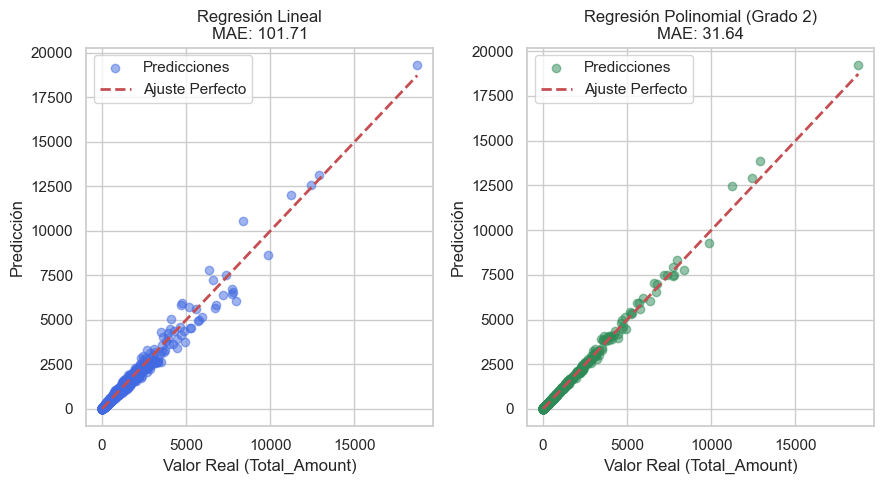

In [21]:
# --------- VISUALIZACIÓN DEL COMPORTAMIENTO DE MODELOS ---------

# Preparar los datos (usamos el set de prueba para ver la realidad)
# Revertimos el logaritmo para ver valor moentario real
y_test_real = np.expm1(y_test_log)
y_pred_lin_real = np.expm1(model_lin.predict(X_test))
y_pred_poly_real = np.expm1(model_poly.predict(X_test))

# Crear la visualización
plt.figure(figsize=(9, 5))

# Modelo Lineal
plt.subplot(1, 2, 1)
plt.scatter(y_test_real, y_pred_lin_real, alpha=0.5, color='royalblue', label='Predicciones')
plt.plot([y_test_real.min(), y_test_real.max()], [y_test_real.min(), y_test_real.max()], 'r--', lw=2, label='Ajuste Perfecto')
plt.title(f'Regresión Lineal\nMAE: {mae_lin:.2f}')
plt.xlabel('Valor Real (Total_Amount)')
plt.ylabel('Predicción')
plt.legend()

# Modelo Polinomial
plt.subplot(1, 2, 2)
plt.scatter(y_test_real, y_pred_poly_real, alpha=0.5, color='seagreen', label='Predicciones')
plt.plot([y_test_real.min(), y_test_real.max()], [y_test_real.min(), y_test_real.max()], 'r--', lw=2, label='Ajuste Perfecto')
plt.title(f'Regresión Polinomial (Grado 2)\nMAE: {mae_poly:.2f}')
plt.xlabel('Valor Real (Total_Amount)')
plt.ylabel('Predicción')
plt.legend()

plt.tight_layout()
plt.show()

Los gráficos confirman lo ya mostrado por las métricas, donde el error modelo lineal es mayor que el polinomial, que se ajusta de forma más exacta a los valores originales.

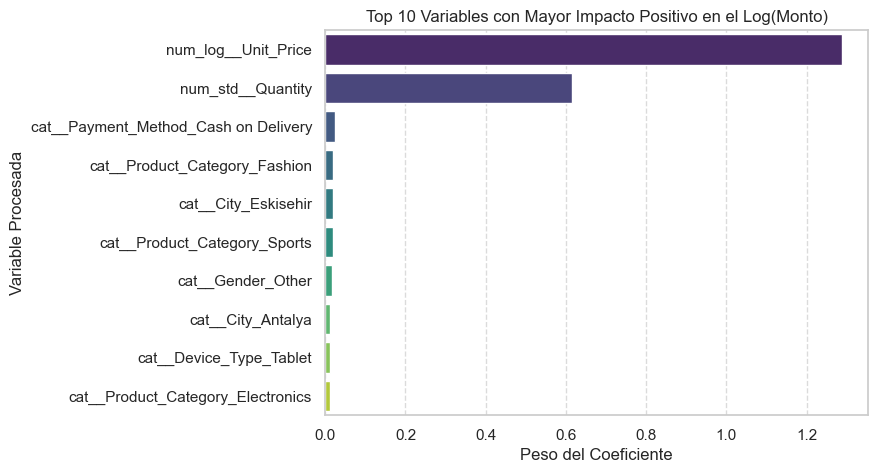


------ VARIABLES RESTANTES ------
                               Variable  Coeficiente
19                      cat__City_Konya     0.010384
24  cat__Product_Category_Home & Garden     0.010287
26           cat__Product_Category_Toys     0.009116
23           cat__Product_Category_Food     0.006551
30   cat__Payment_Method_Digital Wallet     0.006458
31              cat__Device_Type_Mobile     0.004998
9                      cat__Gender_Male     0.004517
13                      cat__City_Bursa     0.004446
15                  cat__City_Gaziantep     0.004160
29       cat__Payment_Method_Debit Card     0.003250
6           num_std__Delivery_Time_Days     0.002184
8        num_std__Is_Returning_Customer     0.002128
4     num_std__Session_Duration_Minutes     0.000050
28      cat__Payment_Method_Credit Card    -0.000362
2                          num_std__Age    -0.001344
18                    cat__City_Kayseri    -0.002052
5                 num_std__Pages_Viewed    -0.002789
7          

In [22]:
# -------- EXTRACCIÓN DE COEFICIENTES PARA MODELO LINEAL ---------

# Extraemos nombres y coeficientes
feature_names = model_lin.named_steps['pre'].get_feature_names_out()
coefficients = model_lin.named_steps['reg'].coef_

# Creamos el DataFrame
df_coefs = pd.DataFrame({'Variable': feature_names, 'Coeficiente': coefficients}).sort_values(by='Coeficiente', ascending=False)

# Visualización de los 10 principales impactos
plt.figure(figsize=(7, 5))

# Gráficar
sns.barplot(data=df_coefs.head(10), x='Coeficiente', y='Variable', hue='Variable', palette='viridis', legend=False)
plt.title('Top 10 Variables con Mayor Impacto Positivo en el Log(Monto)')
plt.xlabel('Peso del Coeficiente')
plt.ylabel('Variable Procesada')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Mostrar los negativos
print("\n------ VARIABLES RESTANTES ------")
print(df_coefs.tail(23))

### Coeficientes modelo lineal

Los coeficientes en el caso de modelo lineal me explican directamente cómo afecta una variable al modelo.

En este caso las dos variables predominantes como ya preveía es Precio Unitario, con una influencia 2.1 veces mayor que la Cantidad, siento este el otro dominante.

Podemos notar que Duración de la sesión tiene un coeficiente cercano a cero, lo que indica que podría ser descartada en caso de reducir dimensionalidad, pues no genera un efecto significativo.

Finalmente hay alrededor de 10 coeficientes que se asocian a un valor negativo, esto quiere decir, que disminuyen el Monto Total, siendo el más fuertes el descuento (num_log__Discount_Amount), lo que sigue la lógica de negocios. Es interesante ver que entre estos encontramos a cuatro cuidades.

### Observaciones

El análisis comparativo demuestra que la Regresión Polinomial de Grado 2 es el modelo óptimo para este problema, logrando explicar el 99.64% de la varianza en datos nuevos y reduciendo el error promedio (MAE) a solo 31.64. 

Mientras que el modelo lineal es excelente para identificar los factores clave (Precio y Cantidad), el polinomial es el ganador indiscutible para la predicción precisa, capturando interacciones complejas que el modelo lineal ignora.

## Algoritmos de clasificación

### ¿Por qué la Clasificación no es adecuada para esta tarea?

En primer ligar variable `Total_Amount` es continua e infinita en teoría. La clasificación está diseñada para etiquetas discretas y finitas, lo que ya no me permite predecir según su naturaleza.

En clasificación se pierde orden y magnitud, la distancia entre clases no importa igual. Si el valor real es 100, un modelo de clasificación vería el error de predecir 101 igual de grave que predecir 500, ya que ambas son simplemente "la clase incorrecta". La regresión entiende que 101 está mucho más cerca de 100.

Por otro lado, si se intentara clasificar cada monto único como una clase, habría miles de categorías, lo que haría que el modelo sea imposible de entrenar por falta de ejemplos suficientes para cada "monto" exacto.

### Implementar KNN

Para realizar un clasificador KNN, se utilizarán los mismos datos, convirtiendo `Total_Amount` en categorías (ej: Gasto Bajo, Medio, Alto)

In [23]:
# --------- MODELO KNN -------- 

# Crear el subconjunto simulado (Categorizando el target)
# Dividimos el gasto en 3 niveles (Bajo, Medio, Alto) usando cuantiles
y_train_cat = pd.qcut(np.expm1(y_train_log), q=3, labels=["Bajo", "Medio", "Alto"])
y_test_cat = pd.qcut(np.expm1(y_test_log), q=3, labels=["Bajo", "Medio", "Alto"])

# Configurar el Pipeline de Clasificación
# Usamos el mismo preprocessor ya definido
knn_pipeline = Pipeline(steps=[('pre', preprocessor), ('clf', KNeighborsClassifier(n_neighbors=5))])

# Entrenar
knn_pipeline.fit(X_train, y_train_cat)

# Predecir
y_pred_knn = knn_pipeline.predict(X_test)

print("--- RESULTADOS CLASIFICADOR KNN ---")
print(f"Accuracy: {accuracy_score(y_test_cat, y_pred_knn):.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test_cat, y_pred_knn))

--- RESULTADOS CLASIFICADOR KNN ---
Accuracy: 0.7220

Reporte de Clasificación:
              precision    recall  f1-score   support

        Alto       0.81      0.73      0.77       333
        Bajo       0.77      0.86      0.81       334
       Medio       0.59      0.58      0.58       333

    accuracy                           0.72      1000
   macro avg       0.72      0.72      0.72      1000
weighted avg       0.72      0.72      0.72      1000



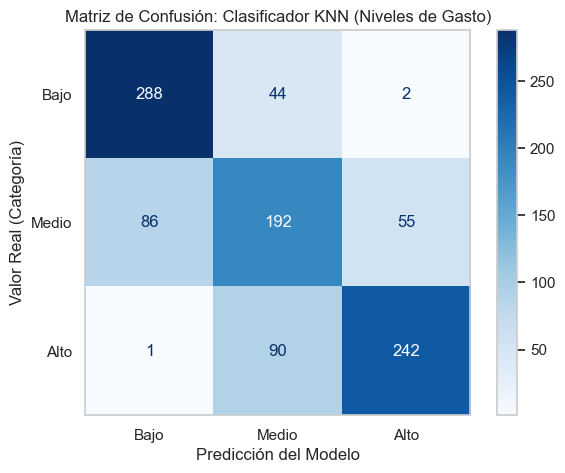

In [24]:
# -------- MATRIZ DE CONFUSIÓN --------

# Calcular la matriz de confusión
# y_test_cat son las etiquetas reales, y_pred_knn son las predicciones del KNN
cm = confusion_matrix(y_test_cat, y_pred_knn, labels=["Bajo", "Medio", "Alto"])

# Visualización
fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Bajo", "Medio", "Alto"])

# Grafica
ax.grid(False)
disp.plot(cmap='Blues', ax=ax)
plt.title('Matriz de Confusión: Clasificador KNN (Niveles de Gasto)')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real (Categoría)')
plt.show()

### Análisis del Clasificador KNN 
El modelo KNN alcanzó un Accuracy de 0.7220, lo que significa que acierta aproximadamente en 7 de cada 10 clasificaciones de nivel de gasto.

Desempeño por categoría:

- Bajo: Es la categoría que mejor identifica, con un f1-score de 0.81. Esto es común, ya que los gastos bajos suelen tener patrones más uniformes.
    - Clasificó 288 de forma correcta, de un total de 334.
    - 44 como medio (sector crítico).
    - 2 como alto.
- Alto: Tiene una buena precisión (0.81), pero un recall más bajo (0.73), lo que indica que se le escapan algunos grandes compradores.
    - Clasificó 242 de forma correcta, de un total de 333.
    - 90 como medio (sector crítico).
    - 1 como bajo.
- Medio: Es el punto débil del modelo (f1-score de 0.58). Al ser una categoría "sándwich", el KNN confunde frecuentemente estos valores con los extremos (Bajo o Alto).
    - Clasificó 192 de forma correcta, de un total de 333.
    - 86 como bajo.
    - 55 como alto.

El modelo sufre en las "fronteras". Un cliente con un gasto justo en el límite entre "Medio" y "Alto" es difícil de clasificar correctamente, lo que genera esa caída en el desempeño.

### Comparación con modelo regresivo

Mientras que el clasificador KNN permite segmentar a los clientes por niveles de gasto con un Accuracy aceptable, pero con ciertos problemas en la frontera (valores medios), se descarta como solución principal debido a que simplifica en exceso el problema. La regresión no solo mantiene la precisión monetaria necesaria para el negocio, sino que preserva la relación matemática continua entre el precio, la cantidad y el monto total, la cual se pierde al categorizar los datos.

| Característica              | Regresión Lineal                         | Regresión Polinomial                      | Clasificador KNN (Simulado)                     |
|----------------------------|------------------------------------------|---------------------------------------------------|------------------------------------------------|
| **Naturaleza del Modelo**  | Predictor Continuo (Línea)               | Predictor Continuo (Curva / Interacción)          | Clasificador Categórico                        |
| **Ajuste (R²) / Accuracy** | 0.9776                                   | 0.9964                                            | 0.7220 (Accuracy)                              |
| **Error Promedio (MAE)**   | 101.71                                   | 31.64                                             | No aplica (Error por clase)                    |
| **Error Relativo Est.**    | ~10.3%                                   | ~3.2%                                             | ~27.8% de desajuste                            |
| **Estabilidad (K-Fold)**   | Alta (+/- 0.0005)                        | Extrema (+/- 0.0000)                              | Moderada (Confusión en clase 'Medio')          |
| **Fortaleza Principal**    | Identifica variables clave.              | Máxima precisión y captura de interacciones.      | Útil para segmentación de marketing.           |
| **Uso Recomendado**        | Análisis descriptivo rápido.             | Proyecciones financieras y auditoría.             | Clasificación de perfiles de cliente.          |

## Métricas de desempeño

In [34]:
# -------- CÁLCULO MÉTRICAS DE DESEMPEÑO --------

# Función para generar métricas impresas
def print_metrics(name, y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_real, y_pred)
    
    print(f"--- MÉTRICAS MODELO: {name} ---")
    print(f"MAE:  {mae:.4f}")
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2:   {r2:.4f}")
    print("-" * 30)
    return [mae, mse, rmse, r2]

# Imprimir resultados en pantalla
results_lin = print_metrics("LINEAL", y_test_real, y_pred_lin_real)
results_poly = print_metrics("POLINOMIAL", y_test_real, y_pred_poly_real)

# Para el KNN, al ser clasificación, imprimimos su Accuracy por separado
print(f"--- MÉTRICAS MODELO: KNN (CLASIFICACIÓN) ---")
print(f"Accuracy: {accuracy_score(y_test_cat, y_pred_knn):.4f}")
print("Nota: MAE/MSE no aplican directamente a etiquetas categóricas.")

--- MÉTRICAS MODELO: LINEAL ---
MAE:  101.7054
MSE:  48820.3970
RMSE: 220.9534
R2:   0.9776
------------------------------
--- MÉTRICAS MODELO: POLINOMIAL ---
MAE:  31.6432
MSE:  7869.8915
RMSE: 88.7124
R2:   0.9964
------------------------------
--- MÉTRICAS MODELO: KNN (CLASIFICACIÓN) ---
Accuracy: 0.7220
Nota: MAE/MSE no aplican directamente a etiquetas categóricas.


## CUADRO COMPARATIVO DE MÉTRICAS Y MODELOS


| Métrica | ¿Qué es? | ¿Qué hace ? | Regresión Lineal | Regresión Polinomial  | KNN (Clasificación) | Interpretación del Resultado | Decisiones que Permite Tomar |
|----------|-----------|---------------------------|------------------|----------------------------------|-----------------------|------------------------------|------------------------------|
| **MAE** (Error Absoluto Medio) | Promedio del error absoluto entre valores reales y predichos. | Mide cuánto se equivoca el modelo en promedio, en las mismas unidades del target. | 101.7054 | 31.6432 | N/A | El modelo polinomial reduce el error promedio en más de 3 veces respecto al lineal. | Elegir el modelo con menor error real promedio para proyecciones financieras más precisas. |
| **MSE** (Error Cuadrático Medio) | Promedio de los errores al cuadrado. Penaliza más los errores grandes. | Evalúa la magnitud del error dando mayor peso a outliers. | 48,820.3970 | 7,869.8915 | N/A | El modelo polinomial reduce drásticamente errores grandes. | Detectar qué modelo es más sensible a valores extremos y cuál es más robusto ante outliers. |
| **RMSE** (Raíz del MSE) | Raíz cuadrada del MSE. | Representa el error típico en la misma unidad del target. | 220.9534 | 88.7124 | N/A | El modelo polinomial tiene un error típico mucho menor en predicción monetaria. | Evaluar impacto práctico del error en términos financieros reales. |
| **R²** (Coeficiente de Determinación) | Proporción de varianza explicada por el modelo. | Indica qué porcentaje del comportamiento del target es explicado por las variables. | 0.9776 | 0.9964 | N/A | El modelo polinomial explica el 99.64% de la variabilidad del monto. | Determinar capacidad explicativa global del modelo y comparar desempeño estructural. |
| **Accuracy** (Exactitud) | Proporción de predicciones correctas en clasificación. | Mide qué tan frecuentemente el modelo clasifica correctamente. | N/A | N/A | 0.7220 | El KNN acierta el 72.2% de las clasificaciones. | Evaluar utilidad del modelo para segmentación o marketing, no para predicción continua. |

### Interpretación de Resultados

Los resultados muestran una mejora significativa al pasar de un modelo de Regresión Lineal a un modelo de Regresión Polinomial.

La Regresión Polinomial reduce considerablemente los errores:

- El MAE disminuye de 101.70 a 31.64.
- El RMSE baja de 220.95 a 88.71.
- El R² aumenta de 0.9776 a 0.9964.

Esto indica que el modelo polinomial captura mejor las interacciones y posibles relaciones no lineales entre las variables predictoras y `Total_Amount`, logrando una mayor precisión en la estimación del monto de compra.

Por otro lado, el modelo KNN fue evaluado bajo un enfoque de clasificación (segmentación del monto), alcanzando una exactitud de 72.2%. Sin embargo, dado que el objetivo principal del proyecto es la predicción de un valor continuo, este modelo no resulta comparable directamente con los modelos de regresión.

En conclusión, la Regresión Polinomial se posiciona como el modelo óptimo para el objetivo del proyecto, al ofrecer mayor precisión, menor error y alta estabilidad en validación cruzada.

## Optimización del modelo

### Pasos a seguir
Tras validar que el modelo polinomial captura con éxito las interacciones de los datos, el siguiente paso es abordar la complejidad estructural y la redundancia (multicolinealidad) que suelen acompañar a estas transformaciones.

- Diagnóstico de Redundancia: Identificar variables altamente correlacionadas mediante el cálculo del VIF (Factor de Inflación de la Varianza) para evaluar la necesidad de simplificación.
- Optimización de Complejidad: Implementar técnicas de Regularización (Lasso) para prevenir el sobreajuste, utilizando GridSearchCV para encontrar el equilibrio perfecto entre sesgo y varianza a través del hiperparámetro $\alpha$.
- Ingeniería de Selección: Observar cómo la regularización actúa como un filtro de ingeniería, priorizando las características que realmente aportan valor predictivo y descartando el ruido.

In [35]:
# ------- EVALUACIÓN DE MULTICOLINEALIDAD -------

# Preparar los datos procesados
# Usamos el preprocessor ya definido
X_processed = preprocessor.fit_transform(X_train)

# Obtenemos los nombres de las columnas para saber qué variable es cada cual
feature_names = preprocessor.get_feature_names_out()
X_vif_df = pd.DataFrame(X_processed, columns=feature_names)

# Calcular el VIF para cada variable
vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif_df.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif_df.values, i) for i in range(X_vif_df.shape[1])]

# Mostrar las 10 variables con mayor redundancia
print("--- ANÁLISIS DE MULTICOLINEALIDAD (VIF) ---")
display(vif_data.sort_values(by="VIF", ascending=False))

--- ANÁLISIS DE MULTICOLINEALIDAD (VIF) ---


,Variable,VIF
28,cat__Payment_Method_Credit Card,3.767408
0,num_log__Unit_Price,3.629708
21,cat__Product_Category_Electronics,3.513946
16,cat__City_Istanbul,3.062898
29,cat__Payment_Method_Debit Card,2.706738
31,cat__Device_Type_Mobile,2.481248
24,cat__Product_Category_Home & Garden,2.434284
30,cat__Payment_Method_Digital Wallet,2.299644
25,cat__Product_Category_Sports,2.273783
11,cat__City_Ankara,2.231451


### Observaciones

No se encontró multicolinealidad en las variables iniciales. Todos tus valores están por debajo de 5. El valor más alto es Payment_Method_Credit Card con 3.76.

Las variables numéricas como Quantity o Age tienen un VIF cercano a 1.0, lo que significa que no tienen ninguna correlación entre sí. Esto explica por qué el modelo lineal ya era muy bueno.

Como se busca trabajar con el modelo polinomial, probablemente en este si se generaron variables con alta colinaliedad, por lo que se aplicará Lasso a este modelo para regularizar esto.

In [27]:
# -------- TÉCNICA DE REGULARIZACIÓN: LASSO CON AJUSTE DE HIPERPARÁMETRO ALPHA --------

# Crear el Pipeline con el Polinomio y Lasso
model_lasso = Pipeline(steps=[
    ('pre', preprocessor),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('reg', Lasso(max_iter=10000)) # Aumentamos iteraciones para que converja
])

# Definir el Grid de Hiperparámetros para 'alpha'
# Probamos valores desde muy pequeños hasta moderados
param_grid = {'reg__alpha': [0.0001, 0.001, 0.01, 0.1, 1.0]}

# Configurar GridSearchCV
# Métrica utilizada: MAE
grid_lasso = GridSearchCV(model_lasso, param_grid, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)

# Entrenar
grid_lasso.fit(X_train, y_train_log)

print(f"Mejor valor de alpha encontrado: {grid_lasso.best_params_['reg__alpha']}")

Mejor valor de alpha encontrado: 0.001


In [36]:
# ------- CANTIDAD DE VARIABLES ELIMINADAS -------

# Obtener el modelo entrenado con el mejor alpha
best_lasso_model = grid_lasso.best_estimator_

# Extraer los coeficientes
coefs = best_lasso_model.named_steps['reg'].coef_

# Contar cuántos son exactamente cero
total_vars = len(coefs)
zero_vars = sum(coefs == 0)
active_vars = sum(coefs != 0)

print(f"Total de variables generadas (Polinomiales): {total_vars}")
print(f"Variables eliminadas por Lasso (Coeficiente = 0): {zero_vars}")
print(f"Variables que realmente aportan al modelo: {active_vars}")

Total de variables generadas (Polinomiales): 594
Variables eliminadas por Lasso (Coeficiente = 0): 580
Variables que realmente aportan al modelo: 14


--- LAS 14 VARIABLES QUE EXPLICAN EL MODELO ---


,Variable,Coeficiente
0,num_log__Unit_Price,1.313701
3,num_std__Quantity,0.746974
34,num_log__Unit_Price num_log__Discount_Amount,0.049242
68,num_log__Discount_Amount num_std__Quantity,0.026297
71,num_log__Discount_Amount num_std__Delivery_Tim...,0.000429
217,num_std__Delivery_Time_Days num_std__Customer_...,0.000177
216,num_std__Delivery_Time_Days^2,0.000177
98,num_std__Age^2,0.000131
159,num_std__Session_Duration_Minutes^2,-0.000009
36,num_log__Unit_Price num_std__Quantity,-0.000397


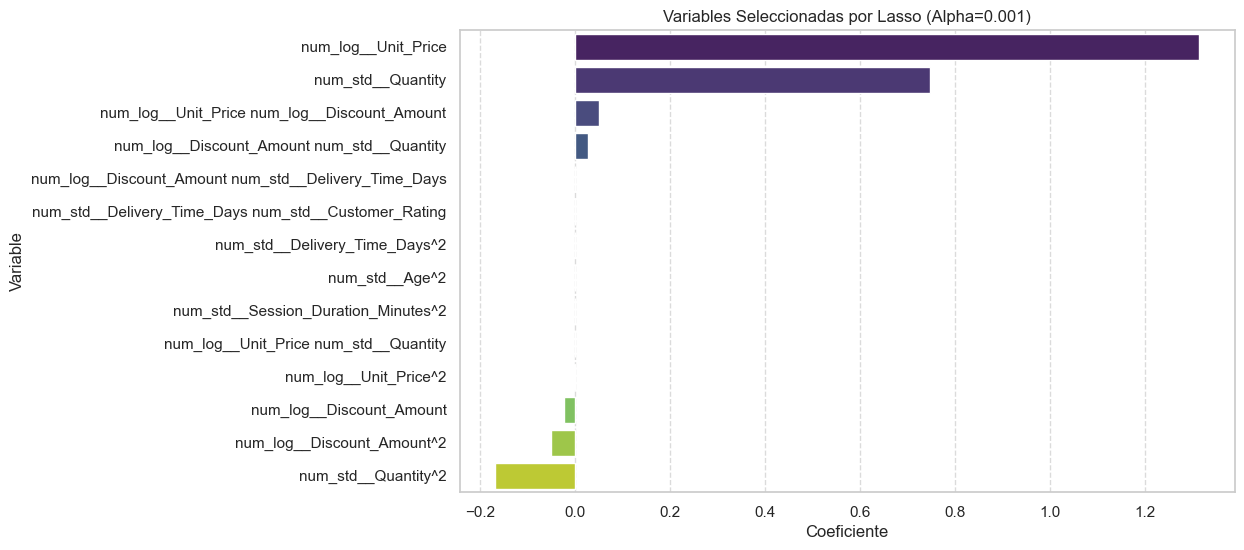

In [37]:
# --------- VARIABLES QUE SE MANTIENEN Y SU PESO (COEFICIENTE) --------

# Obtener nombres de las variables
poly_features = best_lasso_model.named_steps['poly']
base_names = best_lasso_model.named_steps['pre'].get_feature_names_out()
feature_names = poly_features.get_feature_names_out(base_names)

# Filtrar solo las que tienen coeficiente distinto de cero
df_lasso_final = pd.DataFrame({'Variable': feature_names,'Coeficiente': coefs})
df_lasso_final = df_lasso_final[df_lasso_final['Coeficiente'] != 0].sort_values(by='Coeficiente', ascending=False)

print("--- LAS 14 VARIABLES QUE EXPLICAN EL MODELO ---")
display(df_lasso_final)

# Gráfico de barras para las sobrevivientes
plt.figure(figsize=(10, 6))
sns.barplot(data=df_lasso_final, x='Coeficiente', y='Variable', hue='Variable', palette='viridis', legend=False)
plt.title('Variables Seleccionadas por Lasso (Alpha=0.001)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Análisis de las 14 Variables "Maestras"

Las variables principales, num_log__Unit_Price (1.31) y num_std__Quantity (0.74) son, por mucho, los factores más importantes. Esto ya estaba presente en el análisis del modelo lineal. Lo que valida que el modelo ha aprendido correctamente la regla de $Precio \times Cantidad$.

Lasso mantuvo `Unit_Price` * `Discount_Amount`. Lo que indica que el descuento no afecta igual a todos los productos, sino que su impacto depende del precio original. Incluso ambas variables son parte importante de otras relaciones, lo que indica que el modelo rescata su importancia, y como sería lógico pensar el monto de descuento (`Discount_Amount`), es un factor que disminuye el Monto Total.

Al eliminar casi 580 variables, Lasso determinó que factores como el Device_Type (Móvil/Tablet) o ciertas ciudades no influyen linealmente en el monto total de la compra comparado con la potencia del precio y la cantidad.

In [38]:
# ------ MÉTRICAS MEJOR MODELO CON LASSO ------

# Predicciones (Pasar a escala real, sin logaritmo)
y_pred_lasso_log = best_lasso_model.predict(X_test)
y_pred_lasso = np.expm1(y_pred_lasso_log)

# Calcular Métricas con función previamente definida
results_lin = print_metrics("LASSO", y_test_real, y_pred_lasso)

# Polinomial para comparar
results_poly = print_metrics("POLINOMIAL", y_test_real, y_pred_poly_real)

--- MÉTRICAS MODELO: LASSO ---
MAE:  29.3180
MSE:  5664.6767
RMSE: 75.2640
R2:   0.9974
------------------------------
--- MÉTRICAS MODELO: POLINOMIAL ---
MAE:  31.6432
MSE:  7869.8915
RMSE: 88.7124
R2:   0.9964
------------------------------


### Comparación de métricas

Al comparar las métricas, observamos que el modelo Lasso no solo igualó al Polinomial, sino que lo superó ligeramente. 
- Mejora en el MAE: Bajó de 31.64 a 29.31. Ahora el error promedio es de apenas $29$ unidades monetarias.
- Precisión ($R^2$): Subió a 0.9974.
- Reducción de Varianza: Pasar de 594 variables a solo 14 significa que has eliminado el 97% del modelo original que era puro "ruido".

El modelo ahora es mucho más robusto, ganando la simplicidad por sobre una gran cantidad de variables. Se optimizó el MAE y el R², eliminando la multicolinealidad y garantizando un modelo altamente interpretable y eficiente.

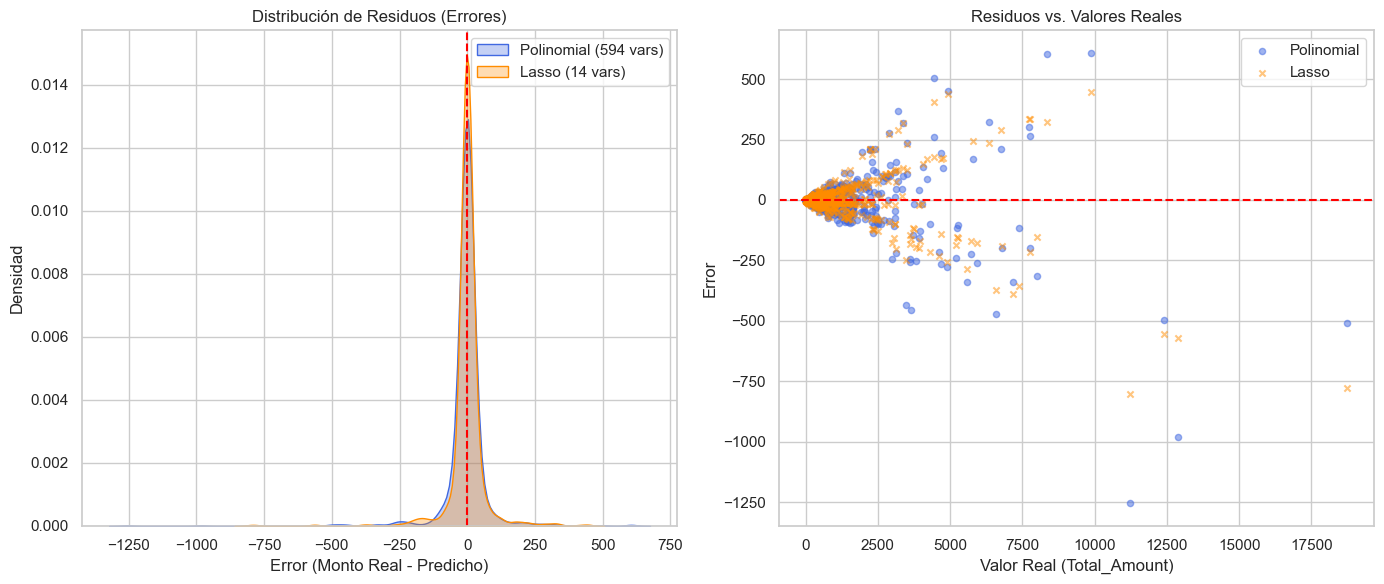

In [39]:
# ------- GRÁFICAS COMPARATIVAS DE RESIDUOS ENTRE MODELO POLINOMIAL Y POLINOMIAL REGULARIZADO (LASSO) -------

# Calcular residuos (Valor Real - Predicción) en escala original
residuos_poly = y_test_real - y_pred_poly_real
residuos_lasso = y_test_real - y_pred_lasso
#residuos_lin = y_test_real - y_pred_lin_real

# Configurar la visualización
plt.figure(figsize=(14, 6))

# Distribución de los errores (Histograma)
plt.subplot(1, 2, 1)
sns.kdeplot(residuos_poly, label=f'Polinomial (594 vars)', fill=True, alpha=0.3, color="royalblue")
sns.kdeplot(residuos_lasso, label=f'Lasso (14 vars)', fill=True, alpha=0.3, color="darkorange")
#sns.kdeplot(residuos_lin, label=f'Lineal (31 vars)', fill=True, alpha=0.3, color="green")
plt.axvline(0, color='red', linestyle='--')
#plt.xlim(-500,500)
plt.title('Distribución de Residuos (Errores)')
plt.xlabel('Error (Monto Real - Predicho)')
plt.ylabel('Densidad')
plt.legend()

# Residuos vs. Valores Reales (Dispersión)
plt.subplot(1, 2, 2)
plt.scatter(y_test_real, residuos_poly, alpha=0.5, label='Polinomial', color="royalblue", s=20)
plt.scatter(y_test_real, residuos_lasso, alpha=0.5, label='Lasso', color="darkorange", s=20, marker='x')
#plt.scatter(y_test_real, residuos_lin, alpha=0.5, label='Lineal', color="green", s=20, marker='o')
plt.axhline(0, color='red', linestyle='--')
#plt.xlim(0,1500)
plt.title('Residuos vs. Valores Reales')
plt.xlabel('Valor Real (Total_Amount)')
plt.ylabel('Error')
plt.legend()

plt.tight_layout()
plt.show()

### Análisis de Residuos y Evaluación de Homocedasticidad

El análisis de la distribución de residuos muestra que el modelo Lasso presenta un comportamiento prácticamente idéntico al modelo polinomial, observándose ambas curvas altamente concentradas alrededor de cero. Esto indica que los errores del modelo son, en general, pequeños y que la simplificación introducida por Lasso no implicó una pérdida significativa de precisión. No obstante, la presencia de colas más extendidas en la distribución sugiere que existen algunos errores mayores asociados principalmente a valores extremos del monto de compra.

Al analizar la relación entre residuos y valores predichos se identifica un ligero patrón de heterocedasticidad, evidenciado por una forma de abanico donde la dispersión de los errores aumenta a medida que crece el monto de compra. En los rangos bajos y medios del gasto, los residuos se concentran cercanos a cero y presentan poca variabilidad, mientras que en montos más elevados la dispersión tiende a incrementarse. Esto sugiere que el modelo logra mayor precisión en compras de menor valor y presenta mayor variabilidad del error en transacciones más grandes.

Este comportamiento es relativamente común en problemas donde la variable objetivo presenta distribuciones sesgadas o con valores extremos, como ocurre frecuentemente con montos de compra. Para abordar este fenómeno se evaluó previamente la aplicación de winsorización en los datos; sin embargo, esta técnica redujo el rendimiento del modelo, generando menores niveles de ajuste y mayores errores, sin mejorar la heterocedasticidad observada.

En este contexto, la transformación logarítmica aplicada a la variable objetivo resulta una estrategia adecuada, ya que permite modelar relaciones en términos relativos y contribuye a estabilizar la varianza. Además, considerando que la mayoría de las observaciones se concentra en rangos bajos y medios del monto de compra, y que los residuos permanecen centrados alrededor de cero, puede concluirse que el modelo presenta un comportamiento general adecuado para el objetivo predictivo planteado.

## Algoritmos de Boosting

In [33]:
# ------- ENTRENAR CON GRADIENTBOOSTINGREGRESSOR AJUSTANDO HIPERPARÁMETROS -------

# Definir el modelo base dentro de un Pipeline (usando preprocessor inicial)
gb_pipeline = Pipeline(steps=[('pre', preprocessor), ('reg', GradientBoostingRegressor(random_state=42))])

# Definir el Grid de Hiperparámetros
# n_estimators: número de árboles
# learning_rate: cuánto aporta cada árbol
# max_depth: profundidad de cada árbol
param_grid_gb = {
    'reg__n_estimators': [100, 300, 500],
    'reg__learning_rate': [0.01, 0.05, 0.1],
    'reg__max_depth': [3, 4, 5]}

# Configurar GridSearchCV, métrica: MAE
grid_gb = GridSearchCV(gb_pipeline, param_grid_gb, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)

# Entrenar el modelo (usamos y_train_log para mantener coherencia con Lasso)
grid_gb.fit(X_train, y_train_log)

# Mejores resultados
print(f"Mejores parámetros: {grid_gb.best_params_}")
best_gb_model = grid_gb.best_estimator_

Mejores parámetros: {'reg__learning_rate': 0.05, 'reg__max_depth': 5, 'reg__n_estimators': 500}


In [40]:
# ------- MÉTRICAS PARA EVALUAR -------

# Realizar la predicción con el mejor modelo encontrado por GridSearchCV
# El resultado estará en la escala logarítmica (y_pred_log)
y_pred_gb_log = best_gb_model.predict(X_test)

# Invertir la transformación logarítmica
# Usamos expm1 para volver a la escala original de "Total_Amount"
y_pred_gb = np.expm1(y_pred_gb_log)

# Calcular e imprimir las métricas comparativas
results_gb = print_metrics("GRADIENT BOOSTING", y_test_real, y_pred_gb)

--- MÉTRICAS MODELO: GRADIENT BOOSTING ---
MAE:  16.8897
MSE:  3519.0834
RMSE: 59.3219
R2:   0.9984
------------------------------


### Análisis y comparación de métricas

El MAE bajó de 29.31 con la versión optimizada (Lasso), a 16.88. Este modelo se equivoca en promedio 16.88 unidades monetarias del Monto Total, alrededor de un 1.7% de error relativo al promedio de esta variable. Lo que lo hace mucho más preciso en cuanto al monto predicho.

El modelo explica el 99,84% de la variabilidad del Monto Total, lo cual es aun mayor que lo explicado por Lasso.

El RMSE bajó de 75 a 59, lo que significa que el Gradient Boosting es mucho más robusto contra los valores atípicos (outliers) que los modelos anteriores, manejando mejor estos puntos.

--- LAS VARIABLES QUE EXPLICAN EL MODELO ---


,Variable,Importancia
0,num_log__Unit_Price,8.077262e-01
3,num_std__Quantity,1.904181e-01
1,num_log__Discount_Amount,1.815480e-03
2,num_std__Age,8.039161e-06
4,num_std__Session_Duration_Minutes,6.154523e-06
5,num_std__Pages_Viewed,6.043599e-06
6,num_std__Delivery_Time_Days,3.864147e-06
7,num_std__Customer_Rating,2.950785e-06
29,cat__Payment_Method_Debit Card,1.004107e-06
17,cat__City_Izmir,9.433204e-07


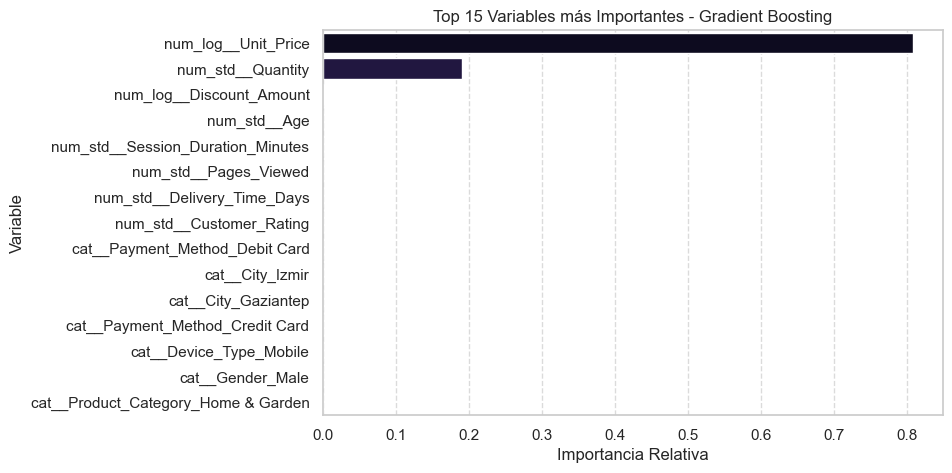

In [41]:
# -------- VARAIBLES EXPLICATIVAS --------

# Extraer las importancias del modelo entrenado
importances = best_gb_model.named_steps['reg'].feature_importances_

# Obtener los nombres de las columnas (del preprocessor original)
feature_names = best_gb_model.named_steps['pre'].get_feature_names_out()

# Crear DataFrame y ordenar
df_importance = pd.DataFrame({'Variable': feature_names, 'Importancia': importances})
df_importance = df_importance.sort_values(by='Importancia', ascending=False).head(15)

print("--- LAS VARIABLES QUE EXPLICAN EL MODELO ---")
display(df_importance)

# Graficar
plt.figure(figsize=(8, 5))
sns.barplot(data=df_importance, x='Importancia', y='Variable', hue='Variable', palette='magma', legend=False)
plt.title('Top 15 Variables más Importantes - Gradient Boosting')
plt.xlabel('Importancia Relativa')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Análisis variables

Al igual que en Lasso este modelo conserva a  `Unit_Price` (~ 80.7%) y `Quantity` (~ 19.0%) como variables determinantes, donde suman casi el 100% de la importancia. Esto confirma que la relación es fundamentalmente matemática y transaccional. 

Considera igual que los otros modelos como una variable importante `Discount_Amount`, de hecho como la tercera con más importancia.

A diferencia de Lasso, el ensamble le da un peso minúsculo pero existente a variables como la Age y Session_Duration. Esto sugiere que existen micro-patrones de comportamiento humano que los árboles de decisión logran captar y que una línea o polinomio ignora.

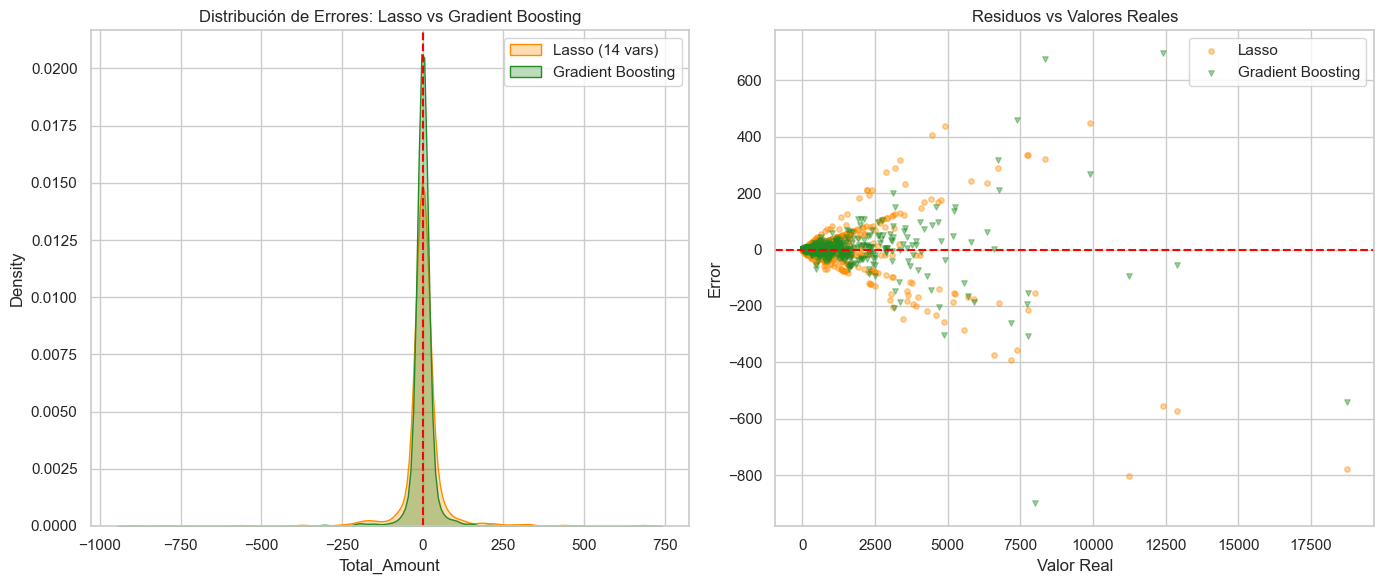

In [42]:
# -------- GRÁFICOS DE RESIDUOS PARA COMPARACIÓN CON LASSO ---------

# Calcular residuos para el Gradient Boosting
residuos_gb = y_test_real - y_pred_gb

# Visualización comparativa
plt.figure(figsize=(14, 6))

# Distribución (KDE)
plt.subplot(1, 2, 1)
sns.kdeplot(residuos_lasso, label='Lasso (14 vars)', fill=True, alpha=0.3, color="darkorange")
sns.kdeplot(residuos_gb, label='Gradient Boosting', fill=True, alpha=0.3, color="forestgreen")
plt.axvline(0, color='red', linestyle='--')
#plt.xlim(-250,250)
plt.title('Distribución de Errores: Lasso vs Gradient Boosting')
plt.legend()

# Dispersión de Errores
plt.subplot(1, 2, 2)
plt.scatter(y_test_real, residuos_lasso, alpha=0.4, label='Lasso', color="darkorange", s=15)
plt.scatter(y_test_real, residuos_gb, alpha=0.4, label='Gradient Boosting', color="forestgreen", s=15, marker='v')
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuos vs Valores Reales')
plt.xlabel('Valor Real')
plt.ylabel('Error')
plt.legend()

plt.tight_layout()
plt.show()

### Análisis gráficos de error

En la distribución la curva verde (Gradient Boosting), es notablemente más alta (un poco más de 0.0200 vs 0.015) y estrecha que la de Lasso. Esto visualiza perfectamente la reducción del MAE, hay muchísimos más registros con error cercano a cero absoluto.

En el gráfico de dispersión los triángulos verdes están mucho más compactos alrededor de la línea roja. Incluso en los valores más altos (más de 10,000), donde Lasso empezaba a dispersarse, el Gradient Boosting se mantiene más cercano a cero.

### Conclusiones del Enfoque Ensemble

Ventajas observadas:

- Precisión Superior: Captura interacciones complejas de forma nativa. Se pudo notar en las métricas y desempeño del modelo.
- Flexibilidad: Se adapta mejor a los datos extremos, como se ve en la reducción del RMSE.

Limitaciones:

- Costo Computacional: Tardó más en entrenar (debido al GridSearchCV) que el modelo Lasso.
- Interpretabilidad: Aunque sabemos qué variables son importantes, no tenemos una "ecuación" simple como en la regresión lineal; es una suma de cientos de árboles.

## Conclusiones generales

### El Flujo de Trabajo y la Potencia del Preprocesamiento

El éxito de este proyecto no radicó solo en los algoritmos, sino en la calidad de los datos.
- Ingeniería de Características: La transformación logarítmica del target y de variables como Unit_Price fue el paso más crítico. Sin esto, la distribución sesgada de los montos habría impedido que los modelos lineales convergieran correctamente.
- Estandarización: El uso de un ColumnTransformer robusto aseguró que variables en escalas distintas (como la edad y los minutos de sesión) no sesgaran el aprendizaje.
- Tratamiento de Categorías: La codificación One-Hot permitió que variables cualitativas como el método de pago o la ciudad aportaran valor predictivo real al sistema.

### Progresión y Evolución de los Modelos
Observamos una curva de aprendizaje clara en el desarrollo del proyecto:
- Inicios (Lineal): Establecieron una línea base sólida ($R^2 \approx 0.97$), pero eran insuficientes para capturar la relación multiplicativa inherente a una venta (Precio $\times$ Cantidad).
- Complejidad (Polinomial): Al elevar el modelo al grado 2, la precisión se disparó, pero a costa de crear un modelo masivo de 594 variables, difícil de mantener y propenso al ruido.
- Optimización (Lasso): Fue el punto de inflexión técnica. Logramos reducir el modelo en un 97%, quedándonos con solo 14 variables esenciales sin perder precisión.
- Excelencia (Gradient Boosting): El enfoque de ensamble demostró que, al corregir errores de forma secuencial, se puede alcanzar un MAE de 16.88, la métrica más baja de todo el estudio.

En resumen se vió una mejora constante y sostenida con cada nuevo modelo.

### Cuadro Comparativo Final

| Modelo                     | MAE (Error) | R² (Precisión) | Recomendación de Uso |
|----------------------------|------------|---------------|----------------------|
| Regresión Lineal           | 101.71     | 0.9776        | Para análisis rápidos y explicaciones de tendencias generales. |
| KNN (Clasificación)        | N/A        | 0.7220 (Acc)  | Para segmentar clientes en rangos de gasto, no para valores exactos. |
| Regresión Polinomial       | 31.64      | 0.9964        | No recomendado por su alta redundancia y costo computacional. |
| Lasso (Polinomial)     | 29.31      | 0.9974        | Ideal para auditoría y negocios: es transparente, ligero y altamente explicable. |
| Gradient Boosting          | 16.89      | 0.9984        | Ideal para producción: máxima precisión para sistemas automatizados de cobro o stock. |

### Recomendación Final
Si el objetivo es una herramienta de soporte a la decisión humana, el modelo Lasso con 14 variables es la mejor opción debido a su balance entre sencillez, exactitud y explicabilidad. Sin embargo, si se busca implementar un motor de predicción automatizado en una plataforma de e-commerce donde cada unidad cuenta, el Gradient Boosting es el estándar de oro por su bajísimo margen de error.